In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Ultralytics ships YOLOv8/v11 + built-in trackers (ByteTrack, BoT-SORT)
!pip install -q ultralytics
import ultralytics
ultralytics.checks()   # prints GPU / versions

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)



image 1/1 /content/drive/MyDrive/Datasets/coco128/images/train2017/000000000009.jpg: 480x640 4 bowls, 1 broccoli, 1 hot dog, 74.1ms
Speed: 6.5ms preprocess, 74.1ms inference, 39.2ms postprocess per image at shape (1, 3, 480, 640)


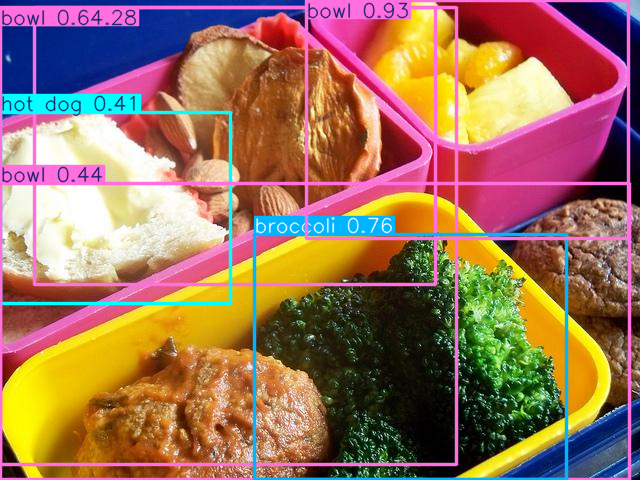

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

In [ ]:
from ultralytics import YOLO

# 'n' = nano (fastest, best for "real-time"); use s/m/l/x for more accuracy
model = YOLO("yolov8n.pt")   # already trained on COCO's 80 classes

# Quick test on one of your dataset images
import os
img_dir = "/content/drive/MyDrive/Datasets/coco128/images/train2017"
sample = os.path.join(img_dir, sorted(os.listdir(img_dir))[0])

results = model(sample)
results[0].show()                       # renders the annotated image inline
print(model.names)                      # the 80 COCO class labels

In [ ]:
# Write a dataset config that points at YOUR drive paths
yaml_text = """
path: /content/drive/MyDrive/Datasets/coco128
train: images/train2017
val: images/train2017          # reusing train as val (demo only)

# COCO's 80 class names
names:
  0: person
  1: bicycle
  2: car
  3: motorcycle
  4: airplane
  5: bus
  6: train
  7: truck
  8: boat
  9: traffic light
  10: fire hydrant
  11: stop sign
  12: parking meter
  13: bench
  14: bird
  15: cat
  16: dog
  17: horse
  18: sheep
  19: cow
  20: elephant
  21: bear
  22: zebra
  23: giraffe
  24: backpack
  25: umbrella
  26: handbag
  27: tie
  28: suitcase
  29: frisbee
  30: skis
  31: snowboard
  32: sports ball
  33: kite
  34: baseball bat
  35: baseball glove
  36: skateboard
  37: surfboard
  38: tennis racket
  39: bottle
  40: wine glass
  41: cup
  42: fork
  43: knife
  44: spoon
  45: bowl
  46: banana
  47: apple
  48: sandwich
  49: orange
  50: broccoli
  51: carrot
  52: hot dog
  53: pizza
  54: donut
  55: cake
  56: chair
  57: couch
  58: potted plant
  59: bed
  60: dining table
  61: toilet
  62: tv
  63: laptop
  64: mouse
  65: remote
  66: keyboard
  67: cell phone
  68: microwave
  69: oven
  70: toaster
  71: sink
  72: refrigerator
  73: book
  74: clock
  75: vase
  76: scissors
  77: teddy bear
  78: hair drier
  79: toothbrush
"""
with open("coco128.yaml", "w") as f:
    f.write(yaml_text)

# Fine-tune (start from pretrained weights)
model = YOLO("yolov8n.pt")
model.train(data="coco128.yaml", epochs=20, imgsz=640, batch=16)

# Best weights are saved here:
best = "runs/detect/train/weights/best.pt"
print("Trained weights:", best)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0,

In [ ]:
# Download a ready-made test video directly (no upload needed)
!wget -q https://github.com/intel-iot-devkit/sample-videos/raw/master/person-bicycle-car-detection.mp4 -O test.mp4

video_path = "test.mp4"

model = YOLO("yolov8n.pt")
results = model.track(
    source=video_path,
    tracker="bytetrack.yaml",
    persist=True,
    save=True,
    conf=0.4
)
print("Annotated video saved under runs/detect/track/")

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 312ms
Prepared 1 package in 56ms
Installed 1 package in 2ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/647) /content/test.mp4: 384x640 (no detections), 79.4ms
video 1/1 (frame 2/647) /c

In [ ]:
import cv2
from collections import defaultdict

model = YOLO("yolov8n.pt")
cap = cv2.VideoCapture(video_path)

w  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or 30
out = cv2.VideoWriter("monitored.mp4",
                      cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

seen_ids = defaultdict(set)   # class_name -> {unique track ids ever seen}

while cap.isOpened():
    ok, frame = cap.read()
    if not ok:
        break

    res = model.track(frame, persist=True, tracker="bytetrack.yaml",
                      conf=0.4, verbose=False)[0]

    if res.boxes.id is not None:
        ids     = res.boxes.id.int().cpu().tolist()
        clss    = res.boxes.cls.int().cpu().tolist()
        boxes   = res.boxes.xyxy.cpu().numpy()
        for tid, c, (x1, y1, x2, y2) in zip(ids, clss, boxes):
            name = model.names[c]
            seen_ids[name].add(tid)
            cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)),
                          (0, 255, 0), 2)
            cv2.putText(frame, f"{name} #{tid}", (int(x1), int(y1) - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # overlay totals (unique objects counted so far)
    y = 30
    for name, s in sorted(seen_ids.items()):
        cv2.putText(frame, f"{name}: {len(s)}", (10, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
        y += 28

    out.write(frame)

cap.release(); out.release()
print("Saved monitored.mp4")

# Re-encode to browser-friendly H.264
!ffmpeg -y -loglevel error -i monitored.mp4 -vcodec libx264 -pix_fmt yuv420p monitored_h264.mp4

# Play the re-encoded version
from IPython.display import HTML
from base64 import b64encode
mp4 = open("monitored_h264.mp4", "rb").read()
HTML(f'<video width=640 controls><source src="data:video/mp4;base64,{b64encode(mp4).decode()}"></video>')

Saved monitored.mp4


<IPython.core.display.Javascript object>

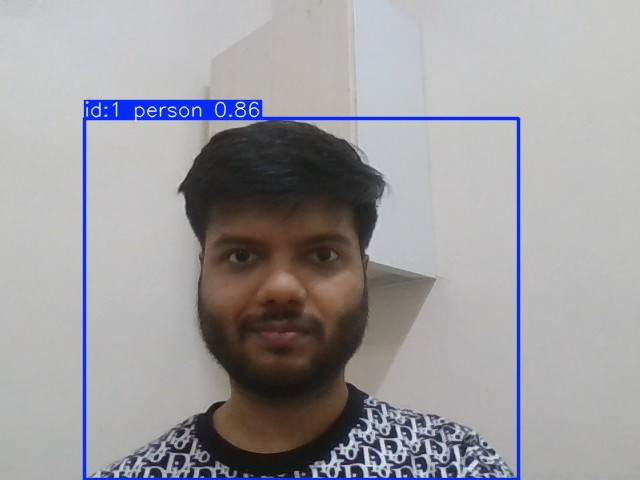

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2, numpy as np

def take_photo(filename="photo.jpg", quality=0.9):
    js = Javascript('''
      async function takePhoto(quality) {
        const div = document.createElement('div');
        const video = document.createElement('video');
        document.body.appendChild(div); div.appendChild(video);
        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        video.srcObject = stream; await video.play();
        await new Promise(r => setTimeout(r, 800));   // warm up
        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth; canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getTracks().forEach(t => t.stop()); div.remove();
        return canvas.toDataURL('image/jpeg', quality);
      }''')
    display(js)
    data = eval_js(f'takePhoto({quality})')
    binary = b64decode(data.split(',')[1])
    with open(filename, "wb") as f:
        f.write(binary)
    return filename

model = YOLO("yolov8n.pt")
frame = cv2.imread(take_photo())
res = model.track(frame, persist=True, conf=0.4, verbose=False)[0]
cv2.imwrite("detected.jpg", res.plot())

from IPython.display import Image
Image("detected.jpg")

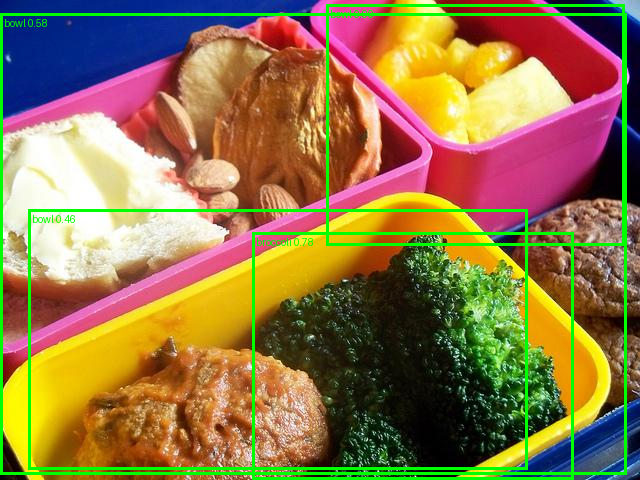

In [ ]:
import torch, torchvision
from torchvision.models.detection import ssd300_vgg16, SSD300_VGG16_Weights
from torchvision.utils import draw_bounding_boxes
from torchvision.io import read_image
import torchvision.transforms.functional as F

weights = SSD300_VGG16_Weights.DEFAULT
ssd = ssd300_vgg16(weights=weights).eval()
labels = weights.meta["categories"]
preprocess = weights.transforms()

img = read_image(sample)                       # the sample from Cell 2
with torch.no_grad():
    pred = ssd([preprocess(img)])[0]

keep = pred["scores"] > 0.4
boxes  = pred["boxes"][keep]
names  = [f"{labels[i]} {s:.2f}"
          for i, s in zip(pred["labels"][keep], pred["scores"][keep])]

out = draw_bounding_boxes(img, boxes, names, width=3, colors="lime")
F.to_pil_image(out)